# Le Petit Prince — do better language models predict the **left** hemisphere better?

Hands-on replication of the core result of
**Bonnasse-Gahot & Pallier (2024)**, *fMRI predictors based on language models of
increasing complexity recover brain left lateralization* ([arXiv:2405.17992](https://arxiv.org/abs/2405.17992)),
on the *average subject* of the Le Petit Prince fMRI corpus.

**The pipeline**

1. `Li2022PetitAverage` study → word events + BOLD, 9 runs.
2. Word-level features from a language model.
3. Convolve with the haemodynamic response and resample to the fMRI TR.
4. Ridge encoding, leave-one-run-out → one Pearson *r* per voxel.
5. Compare left vs right hemisphere.

**Before you start:** run the setup cell below. On Colab it installs everything
for you; locally, follow `README.md` first (`uv pip install -e .`).

**Runtime.** Sections 1-6 give you a full result in about 10 minutes (most of it
the one-off 700 MB data download). Sections 7-8 sweep several models and take
another 30-40 minutes. No GPU is required; if there is one, it is used.

In [1]:
# ---------------------------------------------------------------------------
# Setup. On Google Colab this installs everything and fetches the repository.
# Running locally, it does nothing: you already did `uv pip install -e .`.
# ---------------------------------------------------------------------------
REPO_URL = "https://github.com/BelCorentin/lpp-lateralization-workshop"

import os
import subprocess
import sys

if "google.colab" in sys.modules:
    # Colab already ships a CUDA torch; installing only what is missing keeps
    # this to ~1 minute and avoids a runtime restart.
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "neuralset>=0.2.3",
         "neuralfetch>=0.2.3", "transformers", "praatio", "nilearn"],
        check=True,
    )
    name = REPO_URL.rstrip("/").split("/")[-1]
    if not os.path.isdir(name):
        subprocess.run(["git", "clone", "-q", REPO_URL], check=True)
    os.chdir(name)
    sys.path.insert(0, os.getcwd())
    print("Colab setup done, working in", os.getcwd())
else:
    import lppws  # noqa: F401  -- fails here if `pip install -e .` was skipped
    print("Local install detected")

Local install detected


## 0. Setup

In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

from lppws.study import Li2022PetitAverage, download_data
from lppws import pipeline as pl

# Resolve paths against the repository root, so the notebook works whether the
# kernel starts in `notebooks/` (JupyterLab's default) or at the top level.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
            Path.cwd())
DATA_DIR = Path(os.environ.get("LPP_DIR", ROOT / "data" / "lpp_average_subject_en"))
if not DATA_DIR.exists():
    DATA_DIR = download_data(DATA_DIR.parent)     # ~700 MB, resumable
CACHE = ROOT / "cache"          # feature cache: recomputing embeddings is the slow part

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("root:  ", ROOT)
print("data:  ", DATA_DIR.resolve())
print("device:", DEVICE)

root:   /home/co/git/lpp-lateralization-workshop
data:   /home/co/tmp/li-avg/lpp_average_subject_en
device: cuda


## 1. Study → events

`Li2022PetitAverage` is a `neuralset` Study: it turns a folder on disk into a
tidy DataFrame of typed, timestamped events. Here that is ~1700 `Word` events
per run (onsets read from the TextGrid annotation) and one `Fmri` event pointing
at that run's 4D NIfTI.

In [3]:
study = Li2022PetitAverage(path=str(DATA_DIR), query="timeline_index < 9")
events = study.run()

timelines = list(dict.fromkeys(events["timeline"]))   # 9 runs, in order
print(f"{len(events)} events across {len(timelines)} runs")
print(events["type"].value_counts().to_dict())
events[["type", "start", "duration", "text", "timeline"]].head()

15415 events across 9 runs
{'Word': 15406, 'Fmri': 9}


,type,start,duration,text,timeline
0,Fmri,0.000000,564.000000,NaN,"Li2022PetitAverage:lang=EN,run=1,subject=sub-a..."
1,Word,0.113200,0.615000,once,"Li2022PetitAverage:lang=EN,run=1,subject=sub-a..."
2,Word,0.728200,0.191208,when,"Li2022PetitAverage:lang=EN,run=1,subject=sub-a..."
3,Word,0.919408,0.105479,i,"Li2022PetitAverage:lang=EN,run=1,subject=sub-a..."
4,Word,1.024887,0.133313,was,"Li2022PetitAverage:lang=EN,run=1,subject=sub-a..."


## 2. The fMRI target — mask, hemispheres, mirror homologs

`load_brain` fits a nilearn masker on the study's own `mask_lpp_en.nii.gz`
(detrending, standardisation, 1/128 Hz high-pass) and works out, for every
voxel, its MNI *x* coordinate (→ hemisphere) and the index of its **mirror
homolog** in the other hemisphere. The homolog is what makes the lateralization
measure a *paired* comparison later on.

In [4]:
brain = pl.load_brain(next(DATA_DIR.glob("**/mask_lpp_en.nii.gz")))
print(f"voxels={brain.n_voxels}  left={brain.left.sum()}  right={brain.right.sum()}"
      f"  with a mirror homolog: {brain.valid.mean():.0%}")

# (n_TR, n_voxels) per run. ~1 min: 9 x ~65 MB of NIfTI.
bold = {tl: pl.load_bold(brain, events, tl) for tl in timelines}
{tl.split(',')[-1]: Y.shape for tl, Y in list(bold.items())[:3]}

voxels=25870  left=12425  right=12425  with a mirror homolog: 100%


/home/co/git/lpp-lateralization-workshop/lppws/pipeline.py:80: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  return brain.masker.transform(fp)


{'subject=sub-avgEN': (340, 25870)}

In [5]:
# The 7 left-hemisphere language-network ROIs shipped with the data.
rois = pl.roi_membership(next(DATA_DIR.glob("**/roi_masks")), brain)
lang_left = np.zeros(brain.n_voxels, bool)
for m in rois.values():
    lang_left |= m
print({k: int(v.sum()) for k, v in rois.items()}, "-> union:", int(lang_left.sum()), "voxels")

{'AG_TPJ': 56, 'BA44': 56, 'BA45': 53, 'BA47': 81, 'TP': 59, 'aSTS': 56, 'pSTS': 69} -> union: 430 voxels


## 3. Predictors — word features → HRF → design matrix

`HuggingFaceText` emits one embedding per word. Because the words carry onsets,
the result is a *timed signal*, which `HrfConvolve` convolves with the SPM
haemodynamic response and resamples to the fMRI TR (0.5 Hz). `layers=2/3` picks
a layer two thirds of the way up the network.

We start **non-contextual** (`contextualized=False`): every occurrence of a word
gets the same vector. That is deliberately the weak version — we make it
contextual in section 7.

In [6]:
hrf = pl.hf_features(events, "openai-community/gpt2",
                     contextualized=False, device=DEVICE, cache_dir=CACHE)

X = pl.design_matrix(hrf, events, timelines[0])
print("design matrix for run 1:", X.shape, " (n_TR, n_features)")
print("BOLD for run 1:        ", bold[timelines[0]].shape)

/home/co/git/lpp-lateralization-workshop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


design matrix for run 1: (282, 768)  (n_TR, n_features)
BOLD for run 1:         (282, 25870)


## 4. Ridge encoding, leave-one-run-out

For each of the 9 runs: fit ridge on the other 8, predict the held-out run,
correlate prediction with the real BOLD, per voxel. The 9 correlation maps are
averaged.

The ridge penalty is chosen by `RidgeCV` **inside the training runs only**.
Selecting it on the held-out run is a classic and large source of inflation.

In [7]:
# per_fold=True keeps the 9 held-out-run maps; we need them for a real error bar.
r_static_folds = pl.encode_corr(hrf, events, timelines, bold, per_fold=True)   # ~2 min
r_static = r_static_folds.mean(0)
print(f"per-fold maps: {r_static_folds.shape}")
print(f"mean encoding r over {brain.n_voxels} voxels: {r_static.mean():.4f}")


per-fold maps: (9, 25870)
mean encoding r over 25870 voxels: 0.0266


## 5. Left vs right

Two ways to ask the question:

* **Unpaired** — mean *r* over all left voxels vs all right voxels.
* **Paired** — for each left voxel, its *r* minus the *r* of its right mirror
  homolog. This cancels any global shift in fit quality and is much more
  sensitive.

In [8]:
L, R, li = pl.hemisphere_means(r_static, brain)
print(f"unpaired:  L={L:.4f}  R={R:.4f}   (L-R)/(|L|+|R|) = {li:+.3f}")

d_all = pl.paired_lateralization(r_static, brain)                # all left voxels
d_lang = pl.paired_lateralization(r_static, brain, lang_left)    # language ROIs only
for name, d in [("whole brain", d_all), ("language ROIs", d_lang)]:
    m, lo, hi = pl.bootstrap_ci(d)
    print(f"paired {name:14s}: {m:+.4f}  [{lo:+.4f}, {hi:+.4f}]  (n={d.size} voxels)")

unpaired:  L=0.0286  R=0.0253   (L-R)/(|L|+|R|) = +0.062
paired whole brain   : +0.0034  [+0.0028, +0.0040]  (n=12425 voxels)
paired language ROIs : -0.0040  [-0.0068, -0.0012]  (n=430 voxels)


### How wrong is that confidence interval?

Very. There is only **one subject** here (49 people averaged into one), so the
bootstrap above resamples *voxels*. Neighbouring voxels in a smoothed fMRI map
are strongly correlated, so 430 voxels are nowhere near 430 independent
observations and the interval comes out far too narrow.

A better-behaved (still not perfect) error bar uses the spread **across the 9
held-out runs**: compute the lateralization separately in each fold and look at
how much it moves. The folds share 8/9 of their training data, so this is not a
clean significance test either — but it is the right order of magnitude.


In [9]:
for name, subset in [("whole brain", None), ("language ROIs", lang_left)]:
    v = pl.across_run_ci(r_static_folds, brain, subset)
    print(f"{name:14s}: {v['mean']:+.4f}  [{v['lo']:+.4f}, {v['hi']:+.4f}]"
          f"   positive in {v['runs_positive']}/{v['n_runs']} runs")


whole brain   : +0.0034  [+0.0003, +0.0064]   positive in 6/9 runs
language ROIs : -0.0040  [-0.0141, +0.0061]   positive in 4/9 runs


## 6. Where in the brain?

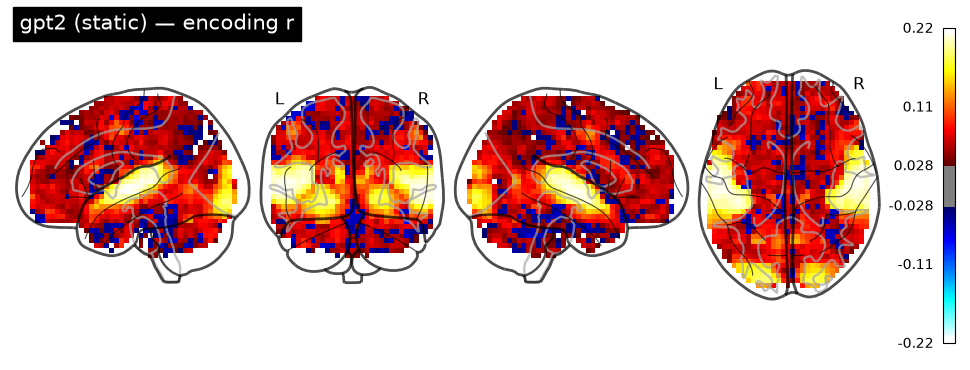

In [10]:
from nilearn import plotting

img = brain.masker.inverse_transform(r_static)
plotting.plot_glass_brain(img, display_mode="lyrz", colorbar=True, plot_abs=False,
                          cmap="cold_hot", title="gpt2 (static) — encoding r")
plotting.show()

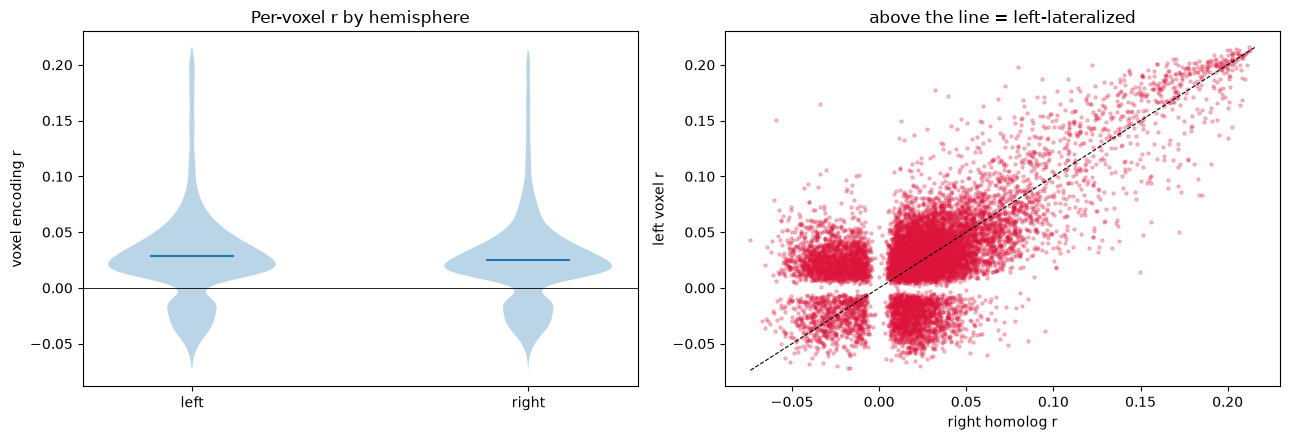

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].violinplot([r_static[brain.left], r_static[brain.right]], showmeans=True, showextrema=False)
ax[0].set_xticks([1, 2]); ax[0].set_xticklabels(["left", "right"])
ax[0].axhline(0, color="k", lw=0.6); ax[0].set_ylabel("voxel encoding r")
ax[0].set_title("Per-voxel r by hemisphere")

sel = brain.left & brain.valid
ax[1].scatter(r_static[brain.pair[sel]], r_static[sel], s=5, alpha=0.25, color="crimson")
lim = [float(min(r_static.min(), 0)), float(r_static.max())]
ax[1].plot(lim, lim, "k--", lw=0.8)
ax[1].set_xlabel("right homolog r"); ax[1].set_ylabel("left voxel r")
ax[1].set_title("above the line = left-lateralized")
plt.tight_layout(); plt.show()

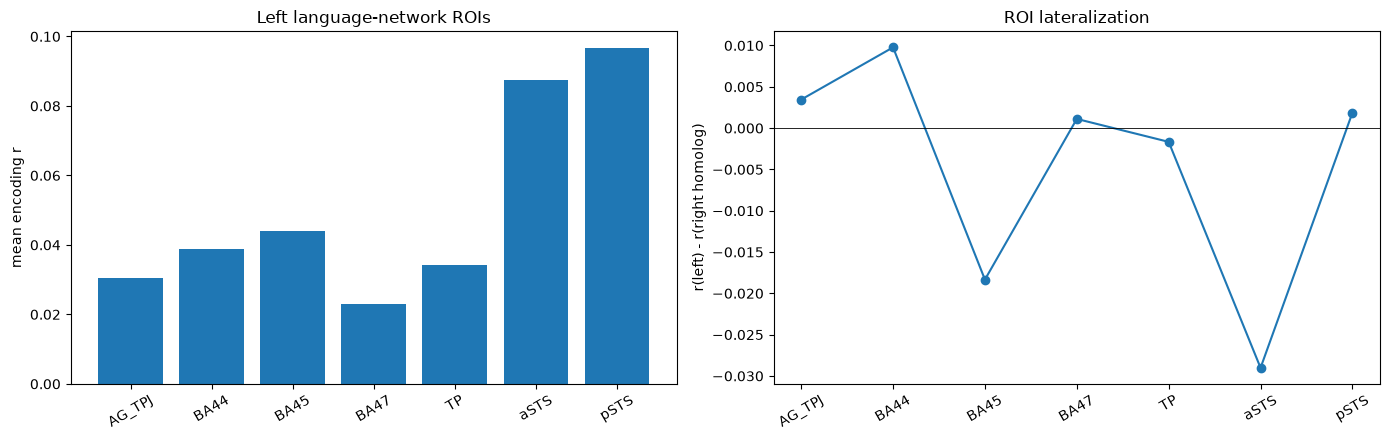

In [12]:
# Per-ROI: encoding quality, and each left ROI against its right-hemisphere homolog.
names = list(rois)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(names, [r_static[m].mean() for m in rois.values()])
ax[0].set_ylabel("mean encoding r"); ax[0].set_title("Left language-network ROIs")
ax[0].tick_params(axis="x", rotation=30)

ax[1].plot(names, [pl.paired_lateralization(r_static, brain, m).mean() for m in rois.values()], "o-")
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_ylabel("r(left) - r(right homolog)"); ax[1].set_title("ROI lateralization")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 7. Does the asymmetry grow with model size?

This is the paper's claim. Two changes make the test sensitive:

1. **Contextual embeddings** — each word is embedded *inside* its running
   context, so the features carry sentence-level information rather than a
   lexicon lookup.
2. **A sweep** over Pythia model sizes (14m → 410m), all at the same final
   checkpoint.

The first run downloads several checkpoints and recomputes embeddings — minutes
and a few GB, then cached in `CACHE`. 410m is the largest that comfortably fits
8 GB of GPU memory.

In [13]:
# Give every Word its running context (the last 32 words, ending with itself).
ctx_events = pl.add_running_context(events, timelines, n_words=32)
print(repr(ctx_events.query("type=='Word'")["context"].iloc[20]))

'once when i was six years old i saw a magnificent picture in a book about the primeval forest called real'


In [14]:
import gc, pandas as pd

SIZES = {
    "14m":  "EleutherAI/pythia-14m",
    "70m":  "EleutherAI/pythia-70m",
    "160m": "EleutherAI/pythia-160m",
    "410m": "EleutherAI/pythia-410m",
    # "1b": "EleutherAI/pythia-1b",   # needs more than 8 GB
}
NPARAMS = {"14m": 1.4e7, "70m": 7e7, "160m": 1.6e8, "410m": 4.1e8, "1b": 1e9}

folds = {}
for tag, name in SIZES.items():
    print("==", tag, flush=True)
    h = pl.hf_features(ctx_events, name, contextualized=True, device=DEVICE, cache_dir=CACHE)
    folds[tag] = pl.encode_corr(h, ctx_events, timelines, bold, per_fold=True)
    del h; gc.collect(); torch.cuda.is_available() and torch.cuda.empty_cache()

results = {t: f.mean(0) for t, f in folds.items()}
df = pd.DataFrame({t: pl.metrics(r, brain, lang_left) for t, r in results.items()}).T
# the honest error bar: spread across held-out runs
df = df.join(pd.DataFrame({t: pl.across_run_ci(f, brain, lang_left) for t, f in folds.items()}).T
             .rename(columns=lambda c: f"run_{c}"))
df

== 14m


== 70m


== 160m


== 410m


,mean_r,LI_global,LI_lang,LI_lang_lo,LI_lang_hi,run_mean,run_lo,run_hi,run_n_runs,run_runs_positive
14m,0.033667,0.004506,0.002606,-0.000114,0.005366,0.002606,-0.006404,0.011617,9.0,5.0
70m,0.035684,0.004478,0.003325,0.000383,0.006126,0.003325,-0.008371,0.015021,9.0,5.0
160m,0.036324,0.004469,0.002561,-0.000465,0.005525,0.002561,-0.009676,0.014797,9.0,5.0
410m,0.036769,0.005004,0.005940,0.002683,0.009074,0.005940,-0.006029,0.017910,9.0,6.0


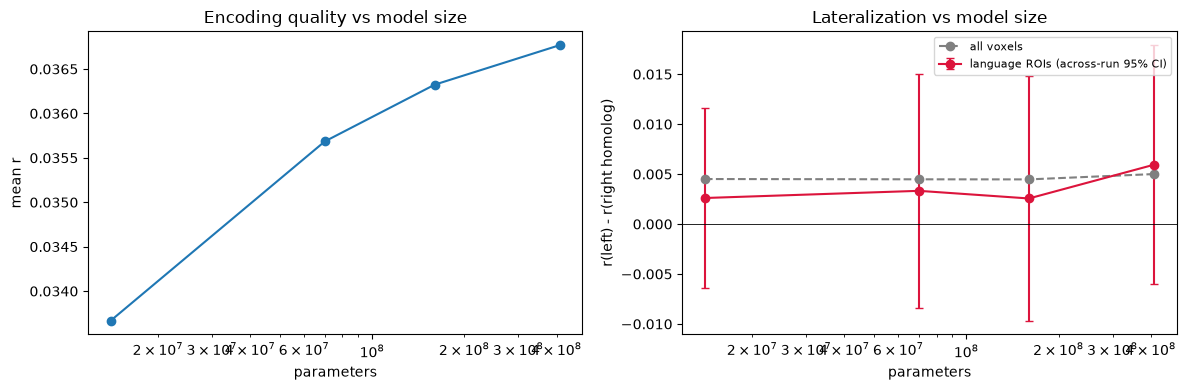

In [15]:
xs = [NPARAMS[t] for t in df.index]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(xs, df["mean_r"], "o-")
ax[0].set_xscale("log"); ax[0].set_xlabel("parameters"); ax[0].set_ylabel("mean r")
ax[0].set_title("Encoding quality vs model size")

yerr = np.array([df["run_mean"] - df["run_lo"], df["run_hi"] - df["run_mean"]])
ax[1].errorbar(xs, df["run_mean"], yerr=yerr, fmt="o-", color="crimson", capsize=3,
               label="language ROIs (across-run 95% CI)")
ax[1].plot(xs, df["LI_global"], "o--", color="gray", label="all voxels")
ax[1].set_xscale("log"); ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_xlabel("parameters"); ax[1].set_ylabel("r(left) - r(right homolog)")
ax[1].set_title("Lateralization vs model size"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 8. The clean complexity axis: **training**

The size sweep above has a problem. Every model was read at the same *relative*
depth, and different architectures put different things at 2/3 of their depth —
so "size" and "which layer we happened to read" vary together. Section 9 shows
how large that confound is.

The training axis has no such problem. Pythia publishes intermediate checkpoints
of the *same* network: same architecture, same width, same layer index, only the
weights differ. Anything that moves along this axis moves because the model
learned, not because we changed where we read.

We take one small model — **pythia-70m** — from random initialisation
(`step1`) to fully trained (`step143000`).

In [16]:
from neuralset.extractors.text import HuggingFaceTextConfig

STEP_MODEL = "EleutherAI/pythia-70m"
STEPS = [1, 512, 2000, 8000, 32000, 143000]   # valid Pythia revisions

step_folds = {}
for st in STEPS:
    print("==", st, flush=True)
    h = pl.hf_features(ctx_events, STEP_MODEL, contextualized=True, device=DEVICE,
                       cache_dir=CACHE,
                       hf_config=HuggingFaceTextConfig(model_kwargs={"revision": f"step{st}"}))
    step_folds[st] = pl.encode_corr(h, ctx_events, timelines, bold, per_fold=True)
    del h; gc.collect(); torch.cuda.is_available() and torch.cuda.empty_cache()

pd.DataFrame({st: pl.metrics(f.mean(0), brain, lang_left)
              for st, f in step_folds.items()}).T[["mean_r", "LI_global", "LI_lang"]]

== 1


== 512


== 2000


== 8000


== 32000


== 143000


,mean_r,LI_global,LI_lang
1,0.026461,0.002804,-0.004698
512,0.026786,0.003490,-0.003605
2000,0.028739,0.003653,-0.002384
8000,0.033343,0.004676,0.001707
32000,0.035159,0.004609,0.003097
143000,0.035684,0.004478,0.003322


### Testing the *trend*, not the points

Each individual checkpoint's lateralization has a wide across-run interval — as
it did in section 5. But the claim is not "this checkpoint is lateralized", it
is "**lateralization grows with training**", and that is a much easier thing to
test: within one held-out run, compare that run against *itself* across
checkpoints. The run's own noise cancels out of its slope.

`trend_test` fits a line per run and tests the 9 slopes against zero.

In [17]:
for metric, subset, label in [("mean_r", None, "encoding quality"),
                              ("LI", None, "lateralization, whole brain"),
                              ("LI", lang_left, "lateralization, language ROIs")]:
    tr = pl.trend_test(step_folds, brain, subset=subset, metric=metric)
    print(f"{label:32s} slope/decade={tr['slope']:+.5f}  t={tr['t']:+.2f}  "
          f"p={tr['p']:.2g}  up in {tr['runs_positive']}/{tr['n_runs']} runs")
    print(f"{'':32s} curve: " + "  ".join(f"{v:+.4f}" for v in tr['curve']))

encoding quality                 slope/decade=+0.00214  t=+5.51  p=0.00056  up in 9/9 runs
                                 curve: +0.0265  +0.0268  +0.0287  +0.0333  +0.0352  +0.0357
lateralization, whole brain      slope/decade=+0.00041  t=+1.85  p=0.1  up in 7/9 runs
                                 curve: +0.0028  +0.0035  +0.0037  +0.0047  +0.0046  +0.0045
lateralization, language ROIs    slope/decade=+0.00186  t=+4.11  p=0.0034  up in 8/9 runs
                                 curve: -0.0047  -0.0036  -0.0024  +0.0017  +0.0031  +0.0033


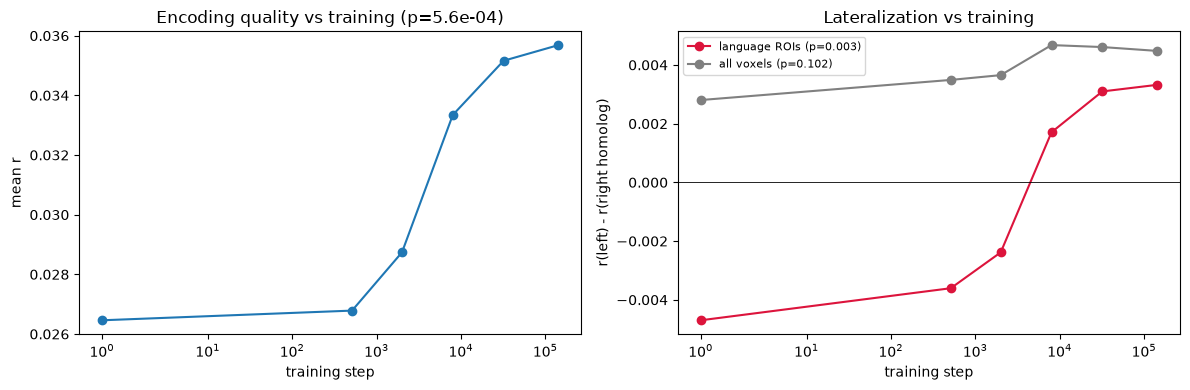

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
mr = pl.trend_test(step_folds, brain, metric="mean_r")
ax[0].plot(STEPS, mr["curve"], "o-")
ax[0].set_xscale("symlog"); ax[0].set_xlabel("training step"); ax[0].set_ylabel("mean r")
ax[0].set_title(f"Encoding quality vs training (p={mr['p']:.1e})")

for subset, lbl, col in [(lang_left, "language ROIs", "crimson"), (None, "all voxels", "gray")]:
    tr = pl.trend_test(step_folds, brain, subset=subset)
    ax[1].plot(STEPS, tr["curve"], "o-", color=col, label=f"{lbl} (p={tr['p']:.3f})")
ax[1].set_xscale("symlog"); ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_xlabel("training step"); ax[1].set_ylabel("r(left) - r(right homolog)")
ax[1].set_title("Lateralization vs training"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

On our run: encoding quality **+0.0021 per decade of training**
(t=+5.5, p=0.0006, up in 9/9 runs) and language-ROI lateralization
**+0.0019 per decade** (t=+4.1, p=0.003, up in 8/9 runs), going from
−0.0047 at random initialisation to +0.0033 fully trained — it *crosses zero*.
The whole-brain effect rises early and then plateaus (p=0.10).

That is the paper's claim, on a 70M-parameter model, with no layer confound.
Note which measure moves: training makes the **language network specifically**
more left-lateralized, while the global asymmetry saturates almost immediately.

## 9. Which layer? (why the size axis is harder)

Everything above read every model at the same *relative* depth, `layers=2/3`.
That choice is not innocent. Sweep it on a single model and compare the spread
you get to the spread the whole size sweep gave you.

In [19]:
LAYERS = [1/3, 2/3, 1.0]
layer_rows = {}
for lay in LAYERS:
    h = pl.hf_features(ctx_events, "openai-community/gpt2", contextualized=True,
                       layers=lay, device=DEVICE, cache_dir=CACHE)
    f = pl.encode_corr(h, ctx_events, timelines, bold, per_fold=True)
    layer_rows[round(lay, 2)] = pl.metrics(f.mean(0), brain, lang_left)
    del h; gc.collect(); torch.cuda.is_available() and torch.cuda.empty_cache()

pd.DataFrame(layer_rows).T[["mean_r", "LI_global", "LI_lang"]]

,mean_r,LI_global,LI_lang
0.33,0.036471,0.004517,0.004207
0.67,0.018049,0.000514,-0.001852
1.00,0.024780,0.002043,-0.007973


On our run this moved `mean r` from 0.037 (layer 1/3) to 0.018 (layer 2/3) and
flipped the sign of the language-ROI lateralization — a bigger swing than the
entire 14m → 410m size sweep produced. See `RESULTS.md` for the numbers.

The practical consequence: a size or training-step curve read at one fixed
relative depth is confounded with where that depth lands inside each network.
Sweep layers first, or report the curve at each model's best layer.

## 10. Where to go next

* **The other checkpoints.** Pythia publishes far more revisions than the six
  used here (`step1000`, `step3000`, ... up to `step143000`). A denser training
  curve costs only compute.
* **Training x size.** Repeat section 8 for `pythia-14m` and `pythia-160m` and
  ask whether the *slope* of the training effect itself grows with size. That
  question is layer-confound-free, unlike comparing sizes at one checkpoint.
* **Best-layer size sweep.** If you do want the size axis, sweep layers for each
  model and compare like with like (see `RESULTS.md`).
* **Context length.** `n_words` in `add_running_context` trades context richness
  against compute.
* **Bigger models** (`pythia-1b`, `1.4b`, `2.8b`) on a machine with more memory.
* **A real error bar.** Everything here rests on 9 runs of *one* averaged
  subject. Rerun on the per-subject data (`Li2022Petit` from `neuralfetch`,
  OpenNeuro ds003643) and bootstrap over subjects.